# IN5437 — Assignment 1
## Question 6: Derivative of Gaussian

**Name:** Benjamine  
**Index:** 258762A

- (a) Show that ∂G/∂x = -(x/σ²) G(x,y) and ∂G/∂y = -(y/σ²) G(x,y).
- (b) Compute 5×5 DoG kernels (x and y) for σ = 2.
- (c) Visualize a 51×51 DoG kernel as a 3D surface plot.
- (d) Apply the DoG kernels to get image gradients.
- (e) Compare with cv.Sobel().

### Question 06.a: Derivation

Starting from:
$$G(x, y) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

Differentiating with respect to x using the chain rule:
$$\frac{\partial G}{\partial x} = \frac{1}{2\pi\sigma^2} \cdot \exp\left(-\frac{x^2+y^2}{2\sigma^2}\right) \cdot \left(-\frac{x}{\sigma^2}\right) = -\frac{x}{\sigma^2} G(x, y)$$

By symmetry:
$$\frac{\partial G}{\partial y} = -\frac{y}{\sigma^2} G(x, y)$$

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 06.b: 5×5 DoG kernels for σ = 2

In [8]:
sigma = 2

# Coordinates from -2 to +2
x = np.arange(-2, 3)
y = np.arange(-2, 3)
xx, yy = np.meshgrid(x, y)

# The Gaussian itself
G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))

# Derivative in x direction
dog_x = -(xx / sigma**2) * G

# Derivative in y direction
dog_y = -(yy / sigma**2) * G

print('5×5 DoG kernel (x direction), σ = 2:')
print(np.round(dog_x, 4))
print('\n5×5 DoG kernel (y direction), σ = 2:')
print(np.round(dog_y, 4))

5×5 DoG kernel (x direction), σ = 2:
[[ 0.0073  0.0053 -0.     -0.0053 -0.0073]
 [ 0.0106  0.0077 -0.     -0.0077 -0.0106]
 [ 0.0121  0.0088 -0.     -0.0088 -0.0121]
 [ 0.0106  0.0077 -0.     -0.0077 -0.0106]
 [ 0.0073  0.0053 -0.     -0.0053 -0.0073]]

5×5 DoG kernel (y direction), σ = 2:
[[ 0.0073  0.0106  0.0121  0.0106  0.0073]
 [ 0.0053  0.0077  0.0088  0.0077  0.0053]
 [-0.     -0.     -0.     -0.     -0.    ]
 [-0.0053 -0.0077 -0.0088 -0.0077 -0.0053]
 [-0.0073 -0.0106 -0.0121 -0.0106 -0.0073]]


### Question 06.c: 51×51 DoG kernel — 3D surface plot

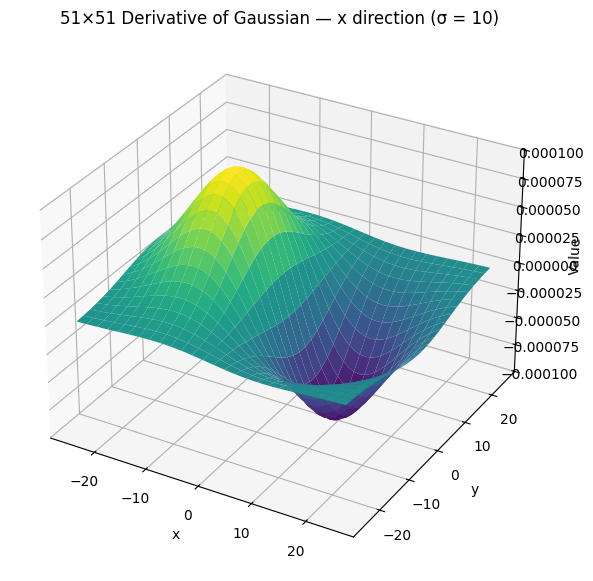

In [9]:
sigma = 10

x = np.arange(-25, 26)
y = np.arange(-25, 26)
xx, yy = np.meshgrid(x, y)

G_51 = (1 / (2 * np.pi * sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
dog_x_51 = -(xx / sigma**2) * G_51

# 3D surface plot of the x-direction DoG
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx, yy, dog_x_51, cmap='viridis')
ax.set_title('51×51 Derivative of Gaussian — x direction (σ = 10)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('Value')
plt.show()

### Question 06.d: Apply DoG kernels to get image gradients

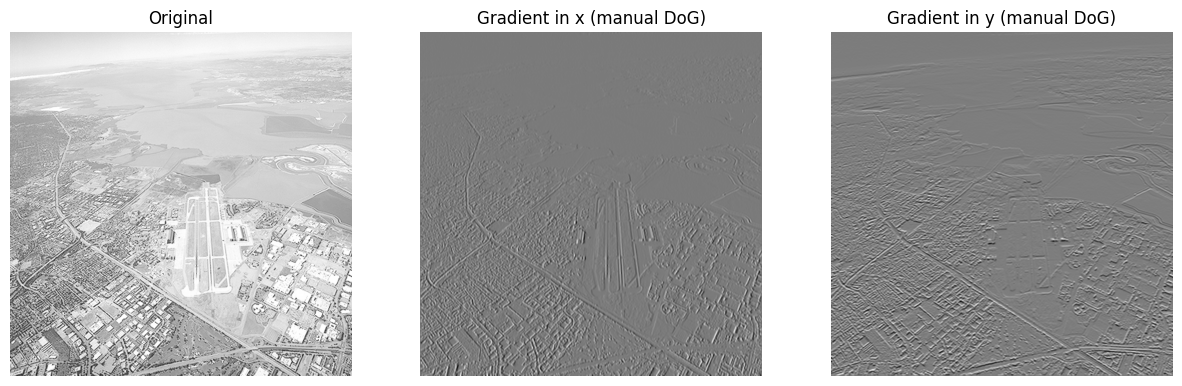

In [10]:
q6_im = cv.imread('../images/runway.png', cv.IMREAD_GRAYSCALE)
assert q6_im is not None, "File could not be read. Check the path."

# Apply DoG kernels. Use CV_32F so negative gradient values are preserved
grad_x = cv.filter2D(q6_im, cv.CV_32F, dog_x)
grad_y = cv.filter2D(q6_im, cv.CV_32F, dog_y)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(q6_im,  cmap='gray', vmin=0, vmax=255);     ax[0].set_title('Original');             ax[0].axis('off')
ax[1].imshow(grad_x, cmap='gray');                       ax[1].set_title('Gradient in x (manual DoG)'); ax[1].axis('off')
ax[2].imshow(grad_y, cmap='gray');                       ax[2].set_title('Gradient in y (manual DoG)'); ax[2].axis('off')
plt.show()

### Question 06.e: Compare with cv.Sobel()

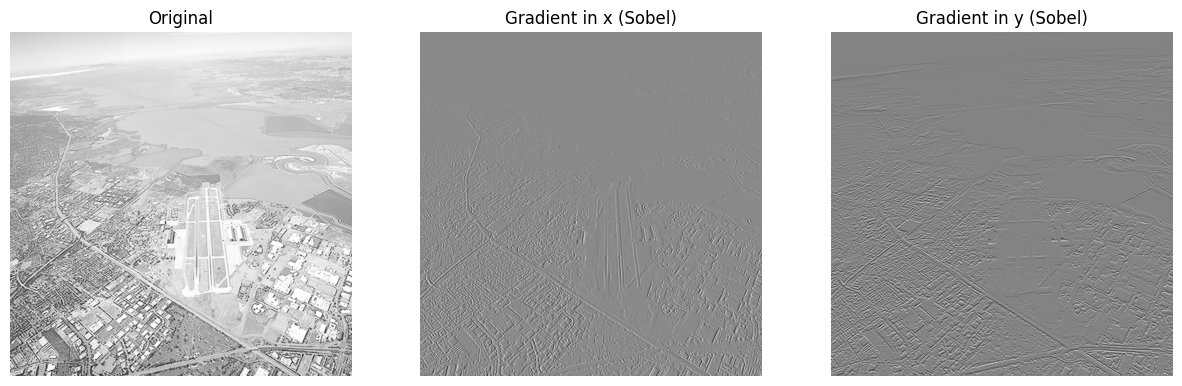

In [11]:
# Sobel gradients (3x3 default kernel)
sobel_x = cv.Sobel(q6_im, cv.CV_32F, 1, 0, ksize=3)
sobel_y = cv.Sobel(q6_im, cv.CV_32F, 0, 1, ksize=3)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(q6_im,   cmap='gray', vmin=0, vmax=255);    ax[0].set_title('Original');             ax[0].axis('off')
ax[1].imshow(sobel_x, cmap='gray');                      ax[1].set_title('Gradient in x (Sobel)'); ax[1].axis('off')
ax[2].imshow(sobel_y, cmap='gray');                      ax[2].set_title('Gradient in y (Sobel)'); ax[2].axis('off')
plt.show()

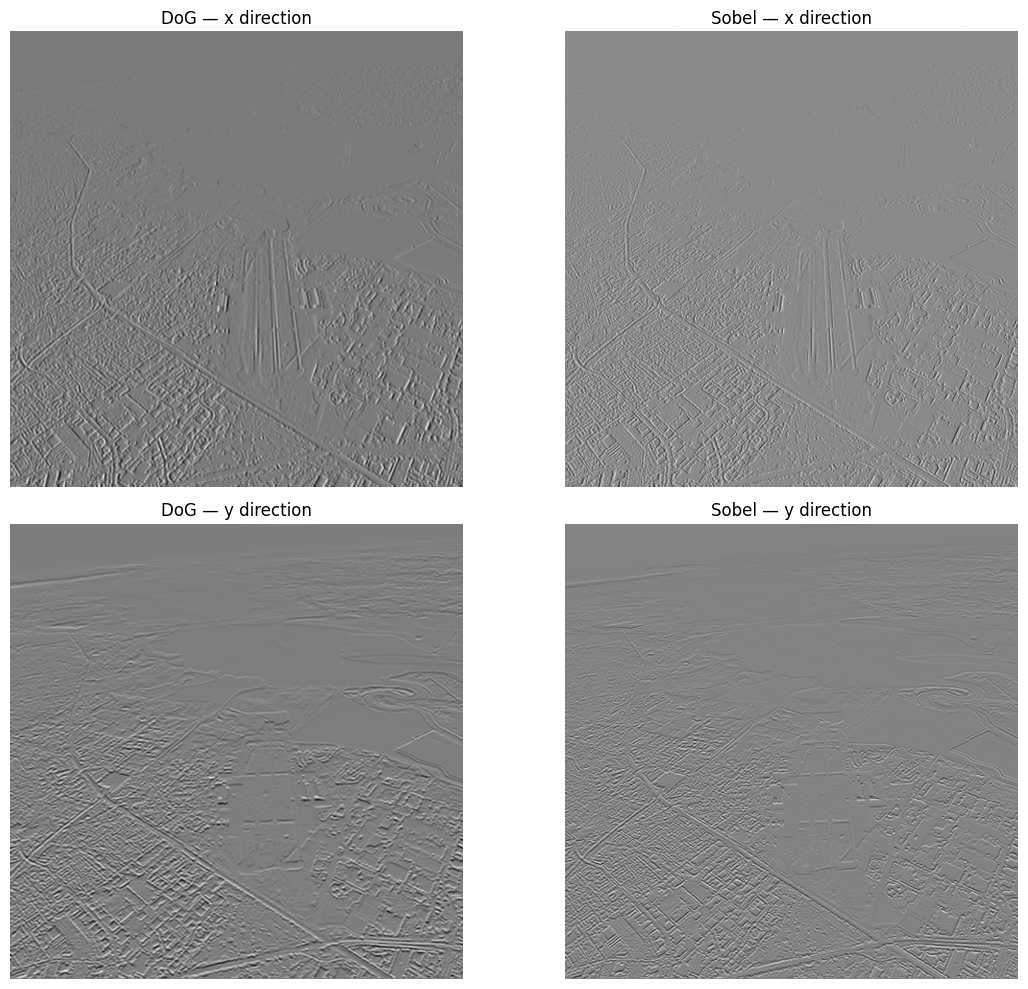

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].imshow(grad_x,  cmap='gray'); ax[0, 0].set_title('DoG — x direction'); ax[0, 0].axis('off')
ax[0, 1].imshow(sobel_x, cmap='gray'); ax[0, 1].set_title('Sobel — x direction'); ax[0, 1].axis('off')
ax[1, 0].imshow(grad_y,  cmap='gray'); ax[1, 0].set_title('DoG — y direction'); ax[1, 0].axis('off')
ax[1, 1].imshow(sobel_y, cmap='gray'); ax[1, 1].set_title('Sobel — y direction'); ax[1, 1].axis('off')
plt.tight_layout()
plt.show()